In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [6]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
performance = pd.read_csv("../data/processed/performance_anomalies.csv")

In [7]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [8]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade


In [10]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav.shape)
print("Performance:", performance.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Performance: (0, 19)


In [11]:
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


In [12]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [13]:
nav.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [16]:
nav["date"] = pd.to_datetime(nav["date"])
nav.info


<bound method DataFrame.info of        amfi_code       date       nav
0         100016 2022-01-03  520.4608
1         100016 2022-01-04  515.0971
2         100016 2022-01-05  521.7239
3         100016 2022-01-06  515.7880
4         100016 2022-01-07  515.1639
...          ...        ...       ...
45995     149324 2026-05-25  292.4810
45996     149324 2026-05-26  291.2707
45997     149324 2026-05-27  288.8007
45998     149324 2026-05-28  280.6873
45999     149324 2026-05-29  279.7511

[46000 rows x 3 columns]>

In [17]:
print("Earliest Date:", nav["date"].min())
print("Latest Date:", nav["date"].max())

Earliest Date: 2022-01-03 00:00:00
Latest Date: 2026-05-29 00:00:00


In [18]:
nav["amfi_code"].nunique()


40

In [19]:
nav.groupby("amfi_code").size()

amfi_code
100016    1150
100025    1150
100033    1150
101206    1150
101207    1150
101208    1150
102885    1150
102886    1150
102887    1150
118632    1150
118633    1150
118634    1150
118635    1150
118636    1150
119092    1150
119093    1150
119094    1150
119095    1150
119120    1150
119551    1150
119552    1150
119598    1150
119599    1150
120503    1150
120504    1150
120505    1150
120506    1150
120507    1150
120841    1150
120842    1150
120843    1150
120844    1150
125497    1150
125498    1150
148567    1150
148568    1150
148569    1150
149322    1150
149323    1150
149324    1150
dtype: int64

In [21]:
nav_plot.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [ ]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)


fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)


fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.show()

In [24]:
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

In [29]:
aum["year"] = aum["date"].dt.year
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


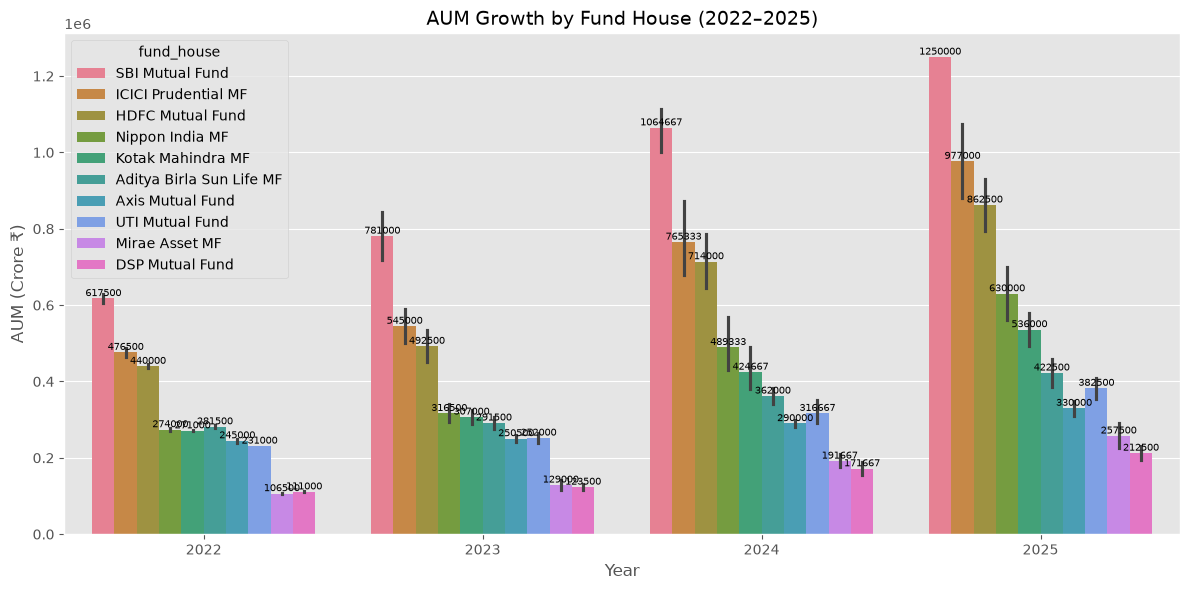

In [31]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("AUM (Crore ₹)")

# Highlight SBI bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=7)

plt.tight_layout()

plt.show()

In [32]:
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

In [36]:
sip.describe()

,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48.000000,48.000000,48.000000,48.000000,36.000000
mean,19577.520833,7.189583,9.893750,8.632083,31.456944
std,6354.329621,1.271457,5.370745,3.613579,11.768190
min,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,25944.250000,8.300000,9.562500,10.525000,40.807500
max,31002.000000,9.350000,46.000000,15.900000,53.050000


In [39]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [40]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2025)",
    markers=True
)

fig.show()

In [41]:
sip["month"] = pd.to_datetime(sip["month"])

In [43]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [46]:
max_sip = sip.loc[sip["sip_inflow_crore"].idxmax()]

In [47]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2025)",
    markers=True
)

fig.add_annotation(
    x=max_sip["month"],
    y=max_sip["sip_inflow_crore"],
    text=f"Highest SIP: ₹{max_sip['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [48]:
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

In [51]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [52]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

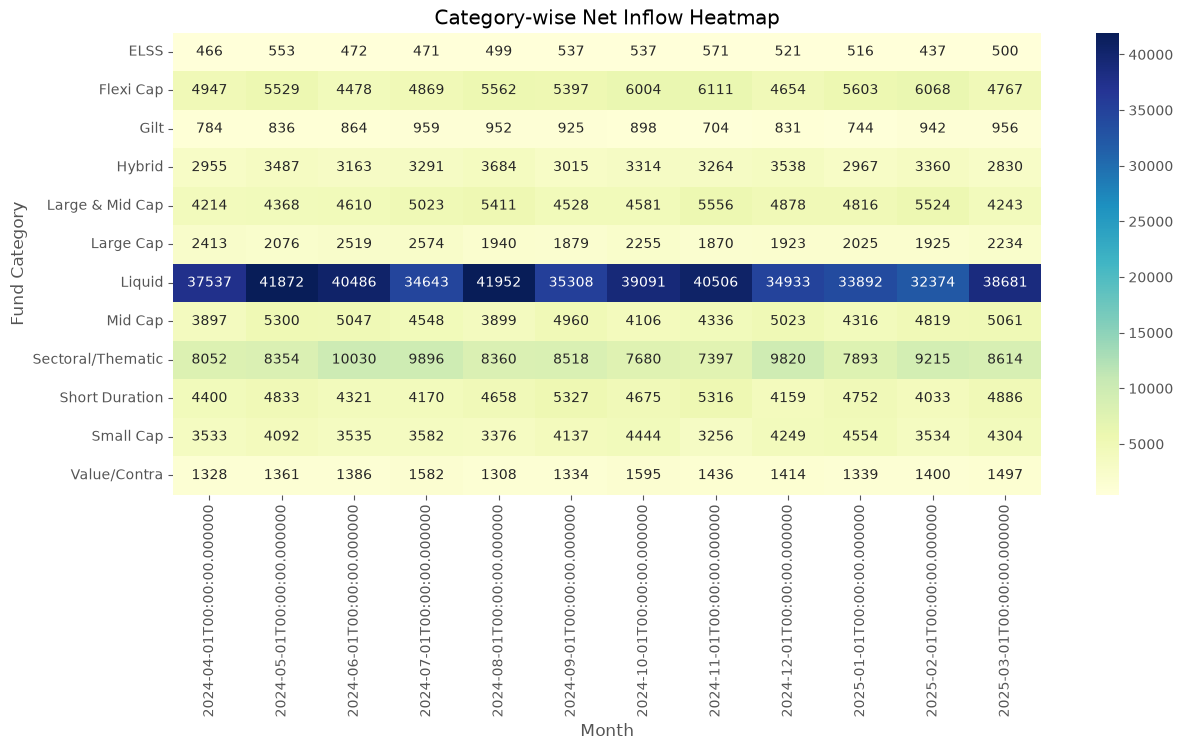

In [ ]:

category["month"] = pd.to_datetime(category["month"])


heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)


plt.figure(figsize=(14,6))


sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)


plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")


plt.show()

In [ ]:
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

transactions.head()

transactions.columns

transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

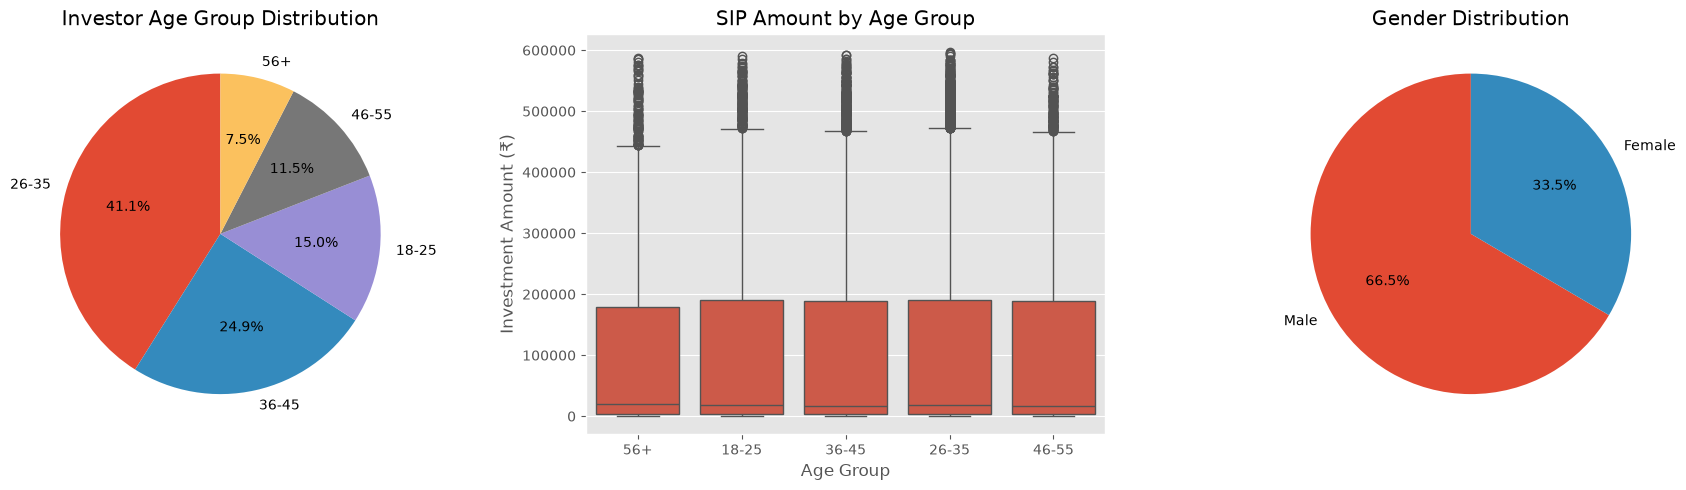

In [10]:
plt.figure(figsize=(18,5))


plt.subplot(1,3,1)

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")


plt.subplot(1,3,2)

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")


plt.subplot(1,3,3)

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.tight_layout()

plt.show()

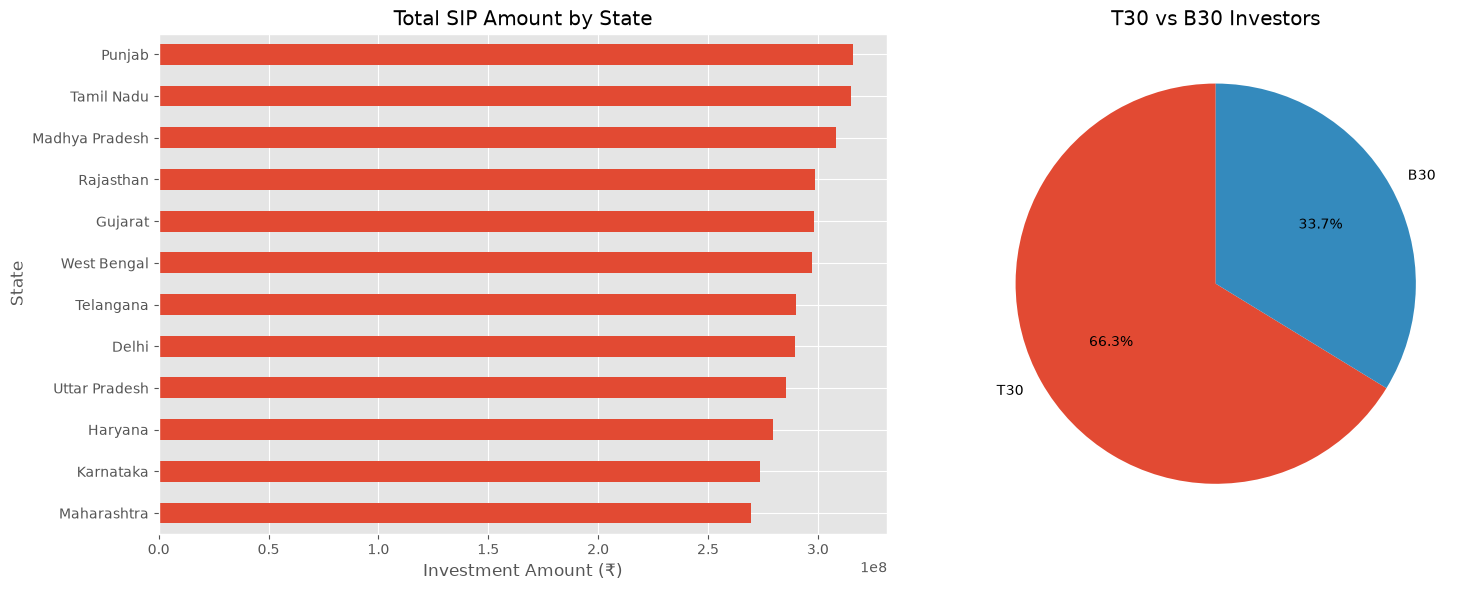

In [11]:
plt.figure(figsize=(16,6))


plt.subplot(1,2,1)

state_data = transactions.groupby("state")["amount_inr"].sum().sort_values()

state_data.plot(kind="barh")

plt.title("Total SIP Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")


plt.subplot(1,2,2)

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investors")
plt.ylabel("")

plt.tight_layout()

plt.show()

In [17]:

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Growth of Mutual Fund Folios (2022–2025)",
    markers=True
)


max_folio = folio.loc[folio["total_folios_crore"].idxmax()]


fig.add_annotation(
    x=max_folio["month"],
    y=max_folio["total_folios_crore"],
    text=f"{max_folio['total_folios_crore']} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [20]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

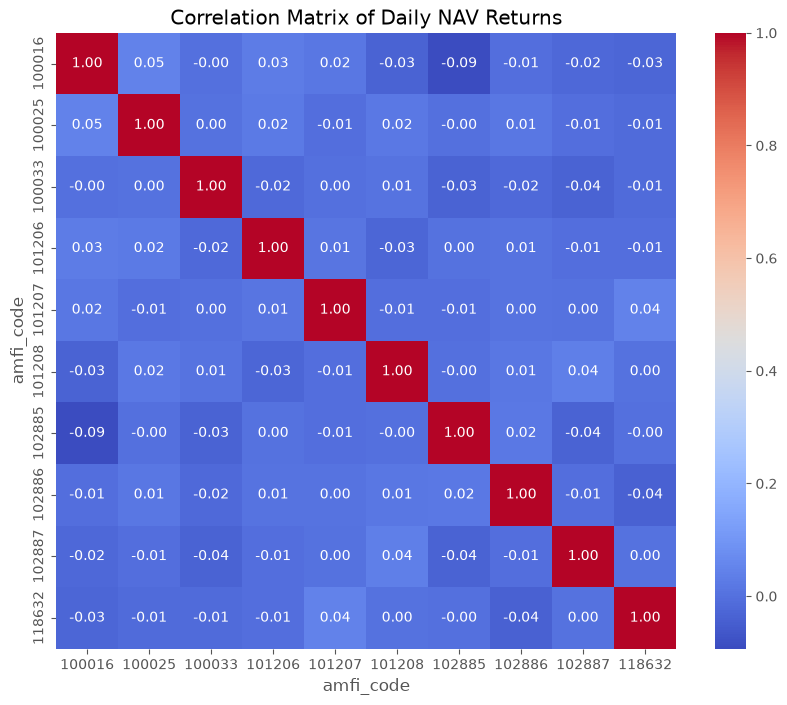

In [21]:

top_funds = nav["amfi_code"].unique()[:10]


nav_10 = nav[nav["amfi_code"].isin(top_funds)]


nav_pivot = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)


daily_returns = nav_pivot.pct_change()


correlation = daily_returns.corr()


plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.show()

In [25]:
portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

In [30]:

sector_data = portfolio.groupby("sector")["weight_pct"].sum()


fig = px.pie(
    values=sector_data.values,
    names=sector_data.index,
    title="Sector Allocation Across Equity Funds",
    hole=0.4
)

fig.show()

# Key EDA Findings

### 1. NAV Trend Analysis
The daily NAV of the selected mutual funds showed an overall upward trend from 2022 to 2025, reflecting long-term market growth.

### 2. Market Movement
The 2023 period showed stronger NAV growth compared to the temporary market correction observed during 2024.

### 3. AUM Growth
SBI Mutual Fund consistently maintained one of the highest Assets Under Management (AUM) among the analyzed fund houses.

### 4. SIP Inflows
Monthly SIP inflows increased steadily over the study period, with the highest recorded inflow occurring in December 2025.

### 5. Category-wise Inflows
Large Cap, Mid Cap, and Flexi Cap categories attracted consistently higher inflows than several other categories.

### 6. Investor Demographics
The majority of investors belonged to the dominant age group shown in the demographic charts, while investment amounts varied across age groups.

### 7. Geographic Distribution
Investment activity was concentrated in a few states, and T30 cities contributed a significant share of total investors.

### 8. Folio Growth
Total mutual fund folios increased consistently from approximately 13.26 crore in 2022 to over 26 crore by the end of 2025, indicating growing investor participation.

### 9. NAV Correlation
Most selected mutual funds exhibited positive correlations in daily returns, suggesting similar responses to market movements.

### 10. Sector Allocation
Banking, IT, Pharma, and other major sectors accounted for a significant portion of portfolio allocation across equity funds.

In [33]:
plt.savefig("../charts/category_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [46]:
fig.write_html("../charts/sip_trend.html")
fig.show()

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

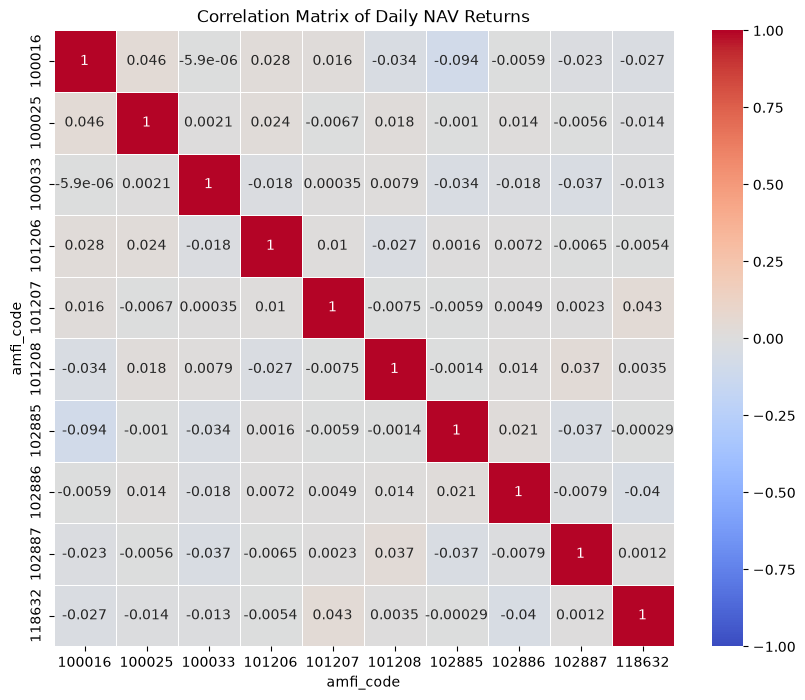

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix of Daily NAV Returns")
plt.show()

day 4

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


nav = pd.read_csv("../data/processed/nav_history_clean.csv")


nav["date"] = pd.to_datetime(nav["date"])


nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()


nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


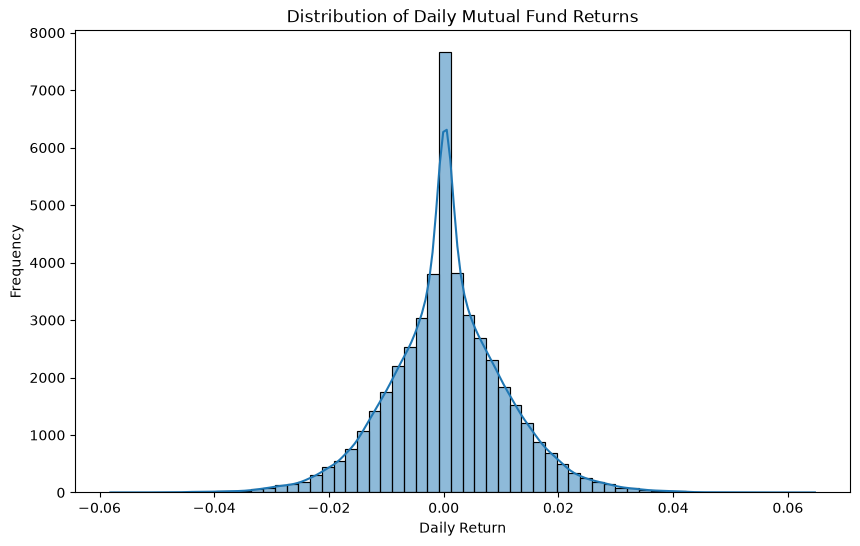

In [3]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Mutual Fund Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [4]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [ ]:

cagr = nav.groupby("amfi_code").agg(
    nav_start=("nav", "first"),
    nav_end=("nav", "last")
)


years = (
    (nav["date"].max() - nav["date"].min()).days
) / 365.25


cagr["cagr"] = (
    (cagr["nav_end"] / cagr["nav_start"]) ** (1 / years)
) - 1


cagr["cagr_percent"] = cagr["cagr"] * 100


cagr.head()

,nav_start,nav_end,cagr,cagr_percent
amfi_code,,,,
100016,520.4608,583.6113,0.026371,2.637074
100025,26.3169,31.8843,0.044582,4.458210
100033,107.3758,342.0072,0.301232,30.123153
101206,305.0996,773.2939,0.235384,23.538361
101207,38.5736,53.9836,0.079388,7.938765


In [6]:
cagr = cagr.sort_values(
    by="cagr_percent",
    ascending=False
)

cagr.head(10)

,nav_start,nav_end,cagr,cagr_percent
amfi_code,,,,
120505,135.8720,473.7640,0.328274,32.827406
119598,89.8738,309.2050,0.324235,32.423536
149324,81.6814,279.7511,0.322874,32.287440
148569,28.8620,97.7435,0.319495,31.949523
148567,70.2514,230.2708,0.309741,30.974108
120843,49.9131,163.2397,0.309075,30.907455
100033,107.3758,342.0072,0.301232,30.123153
149323,78.4622,245.3651,0.295811,29.581087
119094,68.3023,203.8581,0.282144,28.214417


In [7]:
cagr.to_csv("../data/processed/cagr_table.csv")

In [ ]:

risk_free_rate = 0.065


sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean", "std"])


sharpe["annual_return"] = sharpe["mean"] * 252
sharpe["annual_volatility"] = sharpe["std"] * (252 ** 0.5)


sharpe["sharpe_ratio"] = (
    (sharpe["annual_return"] - risk_free_rate)
    / sharpe["annual_volatility"]
)

sharpe.head()

,mean,std,annual_return,annual_volatility,sharpe_ratio
amfi_code,,,,,
100016,0.000142,0.009164,0.035683,0.145481,-0.201517
100025,0.000170,0.002460,0.042854,0.039052,-0.567095
100033,0.001080,0.011929,0.272111,0.189367,1.093699
101206,0.000852,0.009177,0.214647,0.145682,1.027213
101207,0.000424,0.016251,0.106962,0.257973,0.162661


In [9]:
sharpe = sharpe.sort_values(
    by="sharpe_ratio",
    ascending=False
)

sharpe.head(10)

,mean,std,annual_return,annual_volatility,sharpe_ratio
amfi_code,,,,,
148567,0.001074,0.008941,0.270566,0.141937,1.448291
120843,0.001082,0.010008,0.272602,0.158870,1.306744
148569,0.001124,0.011134,0.283262,0.176740,1.234930
119551,0.000917,0.008656,0.231033,0.137414,1.208267
120505,0.001161,0.012152,0.292653,0.192909,1.180101
149323,0.001055,0.011179,0.265908,0.177462,1.132122
100033,0.001080,0.011929,0.272111,0.189367,1.093699
118632,0.000865,0.008913,0.218037,0.141484,1.081659
101206,0.000852,0.009177,0.214647,0.145682,1.027213


In [10]:
sharpe.to_csv("../data/processed/sharpe_ratio.csv")

In [ ]:

risk_free_rate = 0.065


def calculate_sortino(group):
    mean_return = group["daily_return"].mean() * 252

    downside_returns = group[group["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std() * (252 ** 0.5)

    sortino = (mean_return - risk_free_rate) / downside_std

    return pd.Series({
        "annual_return": mean_return,
        "downside_volatility": downside_std,
        "sortino_ratio": sortino
    })


sortino = nav.groupby("amfi_code").apply(calculate_sortino)

sortino.head()

,annual_return,downside_volatility,sortino_ratio
amfi_code,,,
100016,0.035683,0.083513,-0.351047
100025,0.042854,0.023514,-0.941821
100033,0.272111,0.113229,1.829134
101206,0.214647,0.083157,1.799563
101207,0.106962,0.151683,0.276644


In [12]:
sortino = sortino.sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino.head(10)

,annual_return,downside_volatility,sortino_ratio
amfi_code,,,
148567,0.270566,0.086168,2.385644
120843,0.272602,0.087806,2.364320
148569,0.283262,0.101663,2.146914
119551,0.231033,0.077576,2.140267
120505,0.292653,0.112180,2.029353
149323,0.265908,0.107145,1.875101
118632,0.218037,0.082717,1.850133
100033,0.272111,0.113229,1.829134
120504,0.212448,0.081675,1.805294


In [13]:
sortino.to_csv("../data/processed/sortino_ratio.csv")

In [ ]:
from scipy.stats import linregress


benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")


benchmark["date"] = pd.to_datetime(benchmark["date"])


nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()


nifty100 = nifty100.sort_values("date")


nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [20]:
merged = pd.merge(
    nav,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [21]:
results = []

for fund in merged["amfi_code"].unique():

    temp = merged[merged["amfi_code"] == fund].dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    results.append({
        "amfi_code": fund,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta = pd.DataFrame(results)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [22]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [ ]:

nav = nav.sort_values(["amfi_code", "date"])


nav["running_max"] = nav.groupby("amfi_code")["nav"].cummax()


nav["drawdown"] = (nav["nav"] / nav["running_max"]) - 1

nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [ ]:


max_drawdown = nav.groupby("amfi_code")["drawdown"].min().reset_index()

max_drawdown.columns = [
    "amfi_code",
    "max_drawdown"
]

max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [25]:
worst_drawdown_dates = (
    nav.loc[
        nav.groupby("amfi_code")["drawdown"].idxmin(),
        ["amfi_code", "date", "drawdown"]
    ]
)

worst_drawdown_dates.head()

,amfi_code,date,drawdown
183,100016,2022-09-15,-0.247344
1559,100025,2023-07-28,-0.043083
2393,100033,2022-05-12,-0.162172
3842,101206,2023-07-05,-0.112916
5735,101207,2026-05-11,-0.354469


In [26]:
max_drawdown.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

worst_drawdown_dates.to_csv(
    "../data/processed/worst_drawdown_dates.csv",
    index=False
)

In [27]:
expense = pd.read_csv("../data/processed/01_fund_master_clean.csv")

print(expense.columns)

expense.head()

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [ ]:


scorecard = pd.DataFrame()

scorecard["amfi_code"] = cagr.index


scorecard["return_rank"] = cagr["cagr_percent"].rank(ascending=False)


scorecard["sharpe_rank"] = sharpe["sharpe_ratio"].rank(ascending=False)


scorecard["alpha_rank"] = alpha_beta.set_index("amfi_code")["alpha"].rank(ascending=False)


scorecard["expense_rank"] = expense.set_index("amfi_code")["expense_ratio_pct"].rank(ascending=True)

scorecard["drawdown_rank"] = max_drawdown.set_index("amfi_code")["max_drawdown"].rank(ascending=False)

In [31]:
scorecard["weighted_score"] = (
      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["drawdown_rank"] * 0.10
)

In [32]:
scorecard["fund_score"] = (
    (scorecard["weighted_score"].max() - scorecard["weighted_score"])
    /
    (
        scorecard["weighted_score"].max()
        - scorecard["weighted_score"].min()
    )
) * 100

scorecard = scorecard.sort_values(
    by="fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,weighted_score,fund_score
0,120505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,119598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,149324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,148569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,148567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,120843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,100033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,149323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,119094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,119551,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [ ]:

top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[120505, 119598, 149324, 148569, 148567]

In [35]:
top5_nav = nav[
    nav["amfi_code"].isin(top5)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
24150,119598,2022-01-03,89.8738,NaN,89.8738,0.000000
24151,119598,2022-01-04,88.5495,-0.014735,89.8738,-0.014735
24152,119598,2022-01-05,88.0925,-0.005161,89.8738,-0.019820
24153,119598,2022-01-06,88.5175,0.004824,89.8738,-0.015091
24154,119598,2022-01-07,91.4235,0.032830,91.4235,0.000000


In [36]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

top5_nav.head()

,amfi_code,date,nav,daily_return,running_max,drawdown,normalized_nav
24150,119598,2022-01-03,89.8738,NaN,89.8738,0.000000,100.000000
24151,119598,2022-01-04,88.5495,-0.014735,89.8738,-0.014735,98.526489
24152,119598,2022-01-05,88.0925,-0.005161,89.8738,-0.019820,98.017999
24153,119598,2022-01-06,88.5175,0.004824,89.8738,-0.015091,98.490884
24154,119598,2022-01-07,91.4235,0.032830,91.4235,0.000000,101.724307


In [37]:
benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_clean.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values("date")

benchmark["normalized_close"] = (
    benchmark.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

benchmark.head()

,date,index_name,close_value,normalized_close
0,2022-01-03,NIFTY50,17492.79,100.0
5750,2022-01-03,CRISIL_LIQUID,2281.51,100.0
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,100.0
6900,2022-01-03,CRISIL_GILT,1451.06,100.0
1150,2022-01-03,NIFTY100,17778.24,100.0


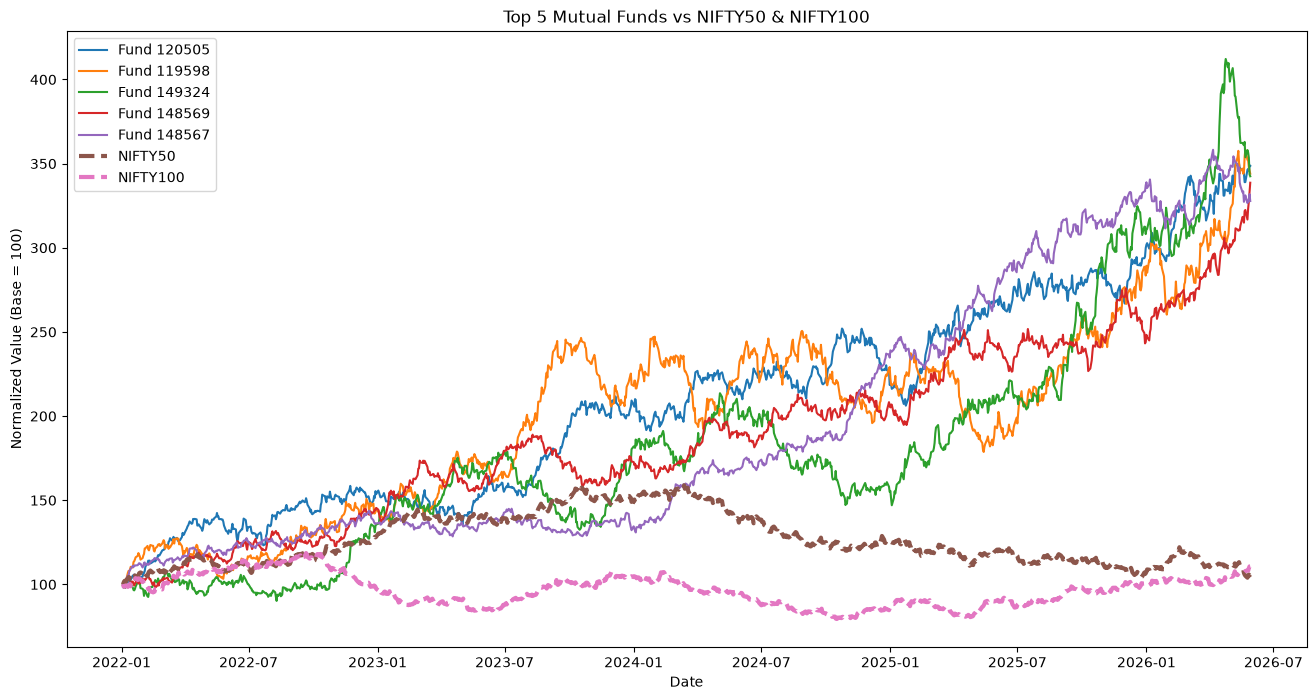

In [ ]:
plt.figure(figsize=(16,8))


for fund in top5:

    temp = top5_nav[
        top5_nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=f"Fund {fund}"
    )


for index in ["NIFTY50", "NIFTY100"]:

    temp = benchmark[
        benchmark["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["normalized_close"],
        linewidth=3,
        linestyle="--",
        label=index
    )

plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.show()

In [39]:
tracking_error = []

for fund in top5:

    temp = merged[
        merged["amfi_code"] == fund
    ].dropna()

    te = (
        (temp["daily_return"] -
         temp["benchmark_return"]).std()
    ) * (252 ** 0.5)

    tracking_error.append({
        "amfi_code": fund,
        "tracking_error": te
    })

tracking_error = pd.DataFrame(tracking_error)

tracking_error

,amfi_code,tracking_error
0,120505,0.231968
1,119598,0.283881
2,149324,0.279170
3,148569,0.217365
4,148567,0.189664


In [40]:
tracking_error.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

plt.savefig(
    "../charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>